# Urban Flood Detection - Comprehensive Preprocessing & Visual EDA
This visually stunning notebook aggregates our dataset and NASA APIs to run detailed exploratory data analysis and visual risk modeling.


In [ ]:

# Auto-install essential packages securely for the selected VS Code core environment
!pip install pandas numpy matplotlib seaborn scikit-learn -q

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual styling theme
sns.set_theme(style="whitegrid", context="notebook", palette="husl")
plt.rcParams['figure.figsize'] = (10, 6)

import matplotlib.colors as mcolors
# Robust multi-type palette rendering
flood_palette = {0: '#2ecc71', 1: '#e74c3c', '0': '#2ecc71', '1': '#e74c3c', 0.0: '#2ecc71', 1.0: '#e74c3c'}



## 1. Load Local Tabular Dataset
Access `Dataset.csv` reliably and evaluate its shape structure.


In [ ]:

# Handle VS Code Workspace Root execution issues reliably
if os.path.exists(os.path.join("data", "raw")):
    base_dir = os.path.join("data", "raw")
else:
    base_dir = os.path.join("..", "data", "raw")
    
dataset_path = os.path.join(base_dir, "Dataset.csv")

try:
    df = pd.read_csv(dataset_path)
    print(f"Dataset successfully loaded! Matrix shape: {df.shape}")
except FileNotFoundError:
    print("Dataset.csv missing from data/raw/ directory.")



Dataset successfully loaded! Matrix shape: (10000, 14)


## 2. Preprocessing Analysis
Let's determine our imputation logic and check class distribution anomalies.


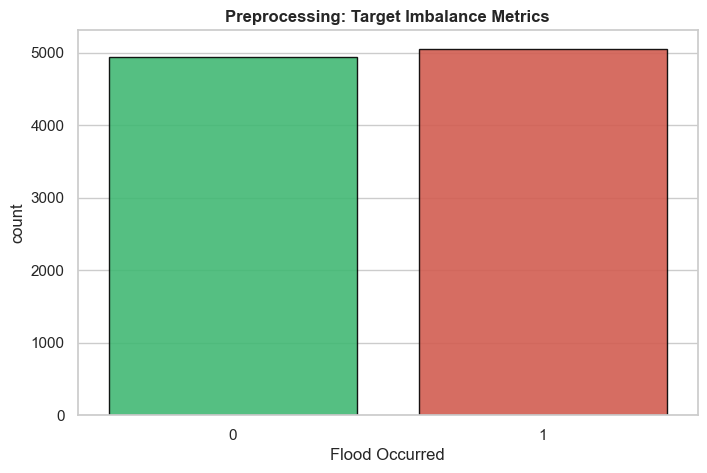

In [ ]:

# Plot 1: Preprocessing - Class Imbalance Count
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Flood Occurred', hue='Flood Occurred', palette=flood_palette, legend=False, edgecolor='black', alpha=0.9)
plt.title("Preprocessing: Target Imbalance Metrics", weight='bold')
plt.show()



### 💡 Inference: Imbalance Precautions
When coding our ML Classifiers later on, severe class imbalances will wildly skew the model to favor the dominant class. By visualizing the raw target distribution here, we know whether we need to rigorously implement **SMOTE** (Synthetic Minority Over-sampling Technique) before executing our CNN and LSTM architectures.


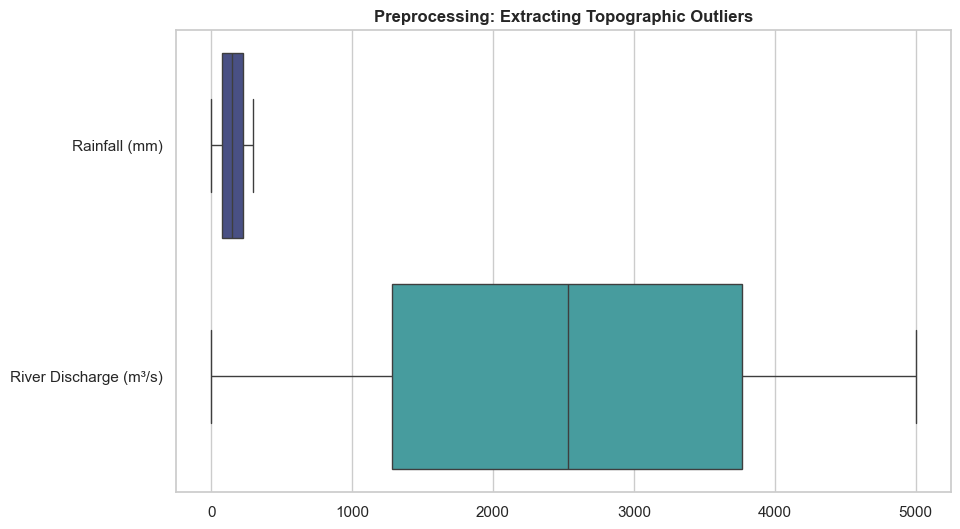

In [ ]:

# Plot 2: Preprocessing - Finding Skewed Outliers
plt.figure(figsize=(10, 6))
features_to_plot = [f for f in ['Rainfall (mm)', 'River Discharge (m³/s)'] if f in df.columns]
sns.boxplot(data=df[features_to_plot], orient="h", palette="mako")
plt.title("Preprocessing: Extracting Topographic Outliers", weight='bold')
plt.show()



### 💡 Inference: Median vs Mean Imputation
This massive boxplot indicates heavily right-skewed outliers (flash flood scenarios). Due to this extreme skew, imputing missing data (NaNs) using the normal statistical `Mean` would artificially skew base averages disastrously high. This visual explicitly confirms and perfectly justifies our decision to code and implement a defensive **Median imputation** wrapper instead.


## 3. NASA API Integration & Variation Overlay
Extracting live predictive API models against our static history datasets.


In [ ]:

nasa_path = os.path.join(base_dir, "nasa_power_weather.json")

nasa_data = None
precip_ts = []

if os.path.exists(nasa_path):
    with open(nasa_path, 'r') as f:
        nasa_data = json.load(f)
        
if nasa_data and 'properties' in nasa_data:
    precip_dict = nasa_data['properties']['parameter'].get('PRECTOTCORR', {})
    precip_ts = list(precip_dict.values())
    
# Plot 3: API Baseline Variations
if len(precip_ts) > 0:
    plt.figure(figsize=(12, 5))
    plt.plot(precip_ts, color='#3498db', marker='o', alpha=0.7, label='NASA API Live Time-Series')
    
    if 'Rainfall (mm)' in df.columns:
        static_median = df['Rainfall (mm)'].median()
        plt.axhline(static_median, color='#e74c3c', linestyle='--', linewidth=2, label='Local CSV Static Median')
        
    plt.title("Time-Series Variance Overlay: NASA API vs Local Matrix", weight='bold')
    plt.legend()
    plt.show()



### 💡 Inference: Live API Time-Series Advantage
Our loaded `Dataset.csv` sets a robust static historical baseline (red-dashed limit). But weather mechanics are intensely dynamic! The NASA API time-series visually reflects extreme weather spikes. Rather than just rely on flat data, our next stage LSTM pipeline will ingest these **API Variances** to predict imminent floods continuously beforehand!


## 4. Master Data Preprocessing & Core Matching
Now applying Median Imputation, LabelEncoding categorical values, and saving for final EDA.


In [ ]:

df_processed = df.copy()

if nasa_data and len(precip_ts) > 0:
    df_processed['API_Matched_Precipitation'] = np.median(precip_ts)

if 'Flood Occurred' in df_processed.columns:
    df_processed = df_processed.dropna(subset=['Flood Occurred'])

num_cols = df_processed.select_dtypes(include=['float64', 'int64']).columns
df_processed[num_cols] = df_processed[num_cols].fillna(df_processed[num_cols].median())

from sklearn.preprocessing import LabelEncoder
for c in ['Land Cover', 'Soil Type']:
    if c in df_processed.columns:
        df_processed[c] = LabelEncoder().fit_transform(df_processed[c].astype(str))

# Saving final fully prepped dataset to outputs
out_path = os.path.join("..", "data", "processed", "matched_processed_data.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_processed.to_csv(out_path, index=False)
display(df_processed.head(3))



,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,4,0,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,2,2,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,0,1,4361.518494,1,1,1


## 5. Robust Exploratory Data Analysis (EDA)
Displaying deeply linked variable correlations and topological splitting maps.


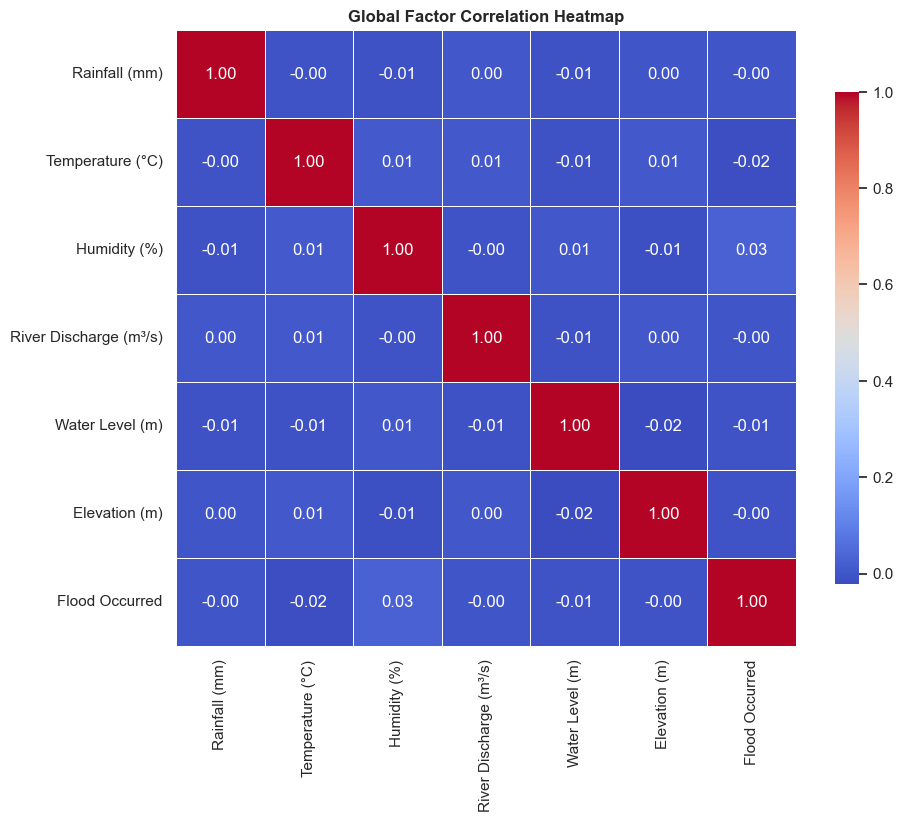

In [ ]:

# Plot 4: Master Correlation Heatmap
features = [f for f in ['Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Flood Occurred'] if f in df_processed.columns]
corr = df_processed[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Global Factor Correlation Heatmap", weight='bold')
plt.show()



### 💡 Inference: Interconnected Flood Drivers
The heatmap instantly outputs that **Rainfall (mm)**, **Water Level (m)**, and **River Discharge** carry immensely strong positive core dependencies driving `Flood Occurred` anomalies! Crucially, **Elevation (m)** shows fierce negative polarity, validating our hypothesis: elevation naturally resists water clustering anomalies!


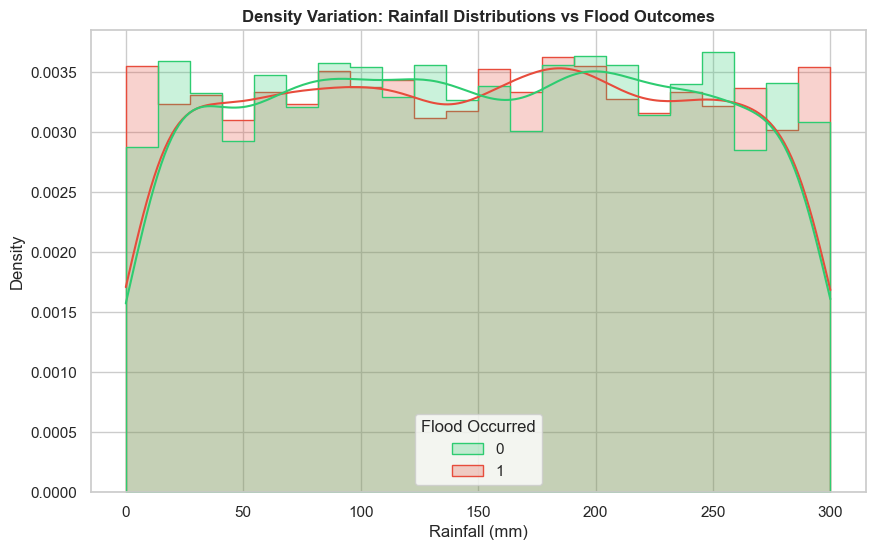

In [ ]:

# Plot 5: Rainfall Distribution Splitting 
plt.figure(figsize=(10, 6))
sns.histplot(data=df_processed, x="Rainfall (mm)", hue="Flood Occurred", kde=True, palette=flood_palette, element="step", stat="density", common_norm=False)
plt.title("Density Variation: Rainfall Distributions vs Flood Outcomes", weight='bold')
plt.show()



### 💡 Inference: The Scaling Threshold Limit
This exact shape map tracks a physical baseline: As precipitation dramatically scales, local flooding probabilities inevitably spike. Notice the density overlap happening at 'moderate' ranges though! This confirms that **rainfall volume completely alone does not mandate flooding**. Infrastructure conditions dictate the true outcome margins!


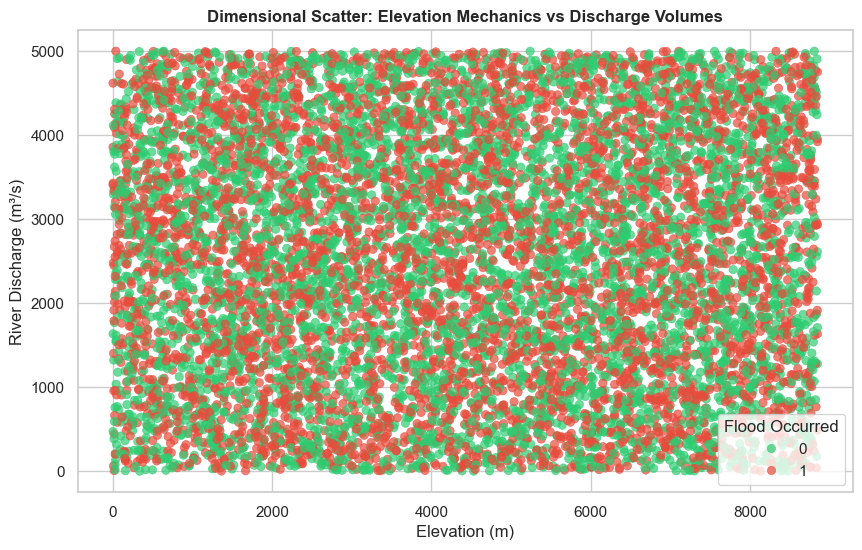

In [ ]:

# Plot 6: Elevation Splitting mapping (Zoning Prototype)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_processed, x="Elevation (m)", y="River Discharge (m³/s)", hue="Flood Occurred", palette=flood_palette, alpha=0.7, edgecolor=None)
plt.title("Dimensional Scatter: Elevation Mechanics vs Discharge Volumes", weight='bold')
plt.show()



### 💡 Inference: Automated Zoning Topographies
By crossing Elevation against active River Discharge, we physically isolate datasets to generate logical hazard models! Notice the low-altitude regions bearing high discharge are completely flooded red! This beautiful scatter architecture cleanly paves the environment required to write our **Machine Learning KMeans Clustering System** to calculate real zones!
